In [54]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images

import numpy as np
import random
from matplotlib import pyplot as plt
import random

# Global variable - Fusion360

In [55]:
def load_saved_tensor(filepath):
    t = torch.load(filepath)
    
    return t

def load_json(filepath):
    with open(filepath, 'r') as fp:
        j = json.load(fp)   # .shape[0]=141245
    
    return j

In [56]:
def save_json(data, dest):
    with open(dest, 'w', encoding='utf8') as fp:
        json.dump(data, fp, indent=4, ensure_ascii=False, sort_keys=False)

    return

In [57]:
rec_seq_path = "model_outputs/rec_seq_0801_161839_last.pt"
ori_seq_path = "model_outputs/ori_seq_0801_161839_last.pt"

rec_seq = load_saved_tensor(rec_seq_path)   # [10377, 10, 512]
ori_seq = load_saved_tensor(ori_seq_path)   # [10377, 10, 512]

all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = load_saved_tensor(all_emb_path)   # [141245, 512]

all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
all_md = load_json(all_md_path)   # .shape[0]=141245  

In [58]:
def compute_aid_to_part_indice_map():
    the_map = dict()
    assert len(all_md) == all_emb.shape[0]
    for idx, md in enumerate(all_md):
        aid = '_'.join(md.split('_')[1:3])
        if aid in the_map:
            the_map[aid].append(idx)
        else:
            the_map[aid] = []
            the_map[aid].append(idx)
    
    return the_map

aid_to_part_indice_map = compute_aid_to_part_indice_map()   # 8146: # assemblies got successfully processed/rendered

print(f'Total number of assemblies: {len(aid_to_part_indice_map)}')

Total number of assemblies: 8146


In [59]:
def compute_md_to_idx_map():
    the_map = dict()
    for idx, md in enumerate(all_md):
        the_map[md] = idx
    
    return the_map

md_to_idx_map = compute_md_to_idx_map()
print(f'Number of parts: {len(md_to_idx_map)}')

Number of parts: 141245


In [60]:
all_part_graph_path = './processed_data/part_graphs_dim=5.json'
all_part_graph = load_json(all_part_graph_path)
valid_aid_list = list(all_part_graph.keys())   # 5462: # assemblies having contact info, also # assemblies in the part graph
print(f'Number of assemblies having contact information / included in the part graph: {len(valid_aid_list)}')

Number of assemblies having contact information / included in the part graph: 5462


# Global variable - CLIP query

In [70]:
clip_query_seq_path = "model_outputs/mech_query_seq_0801_161839_last.pt"
clip_query_seq = load_saved_tensor(clip_query_seq_path)
print(f'Number of clip text queries: {clip_query_seq.shape[0]}')

mech_part_names_path = './processed_data/clip_mech_query_metadata.json'
mech_part_names = load_json(mech_part_names_path)
assert clip_query_seq.shape[0] == len(mech_part_names['mech_name'])

Number of clip text queries: 26


# Global variable - ABC

In [7]:
abc_query_seq_path = "model_outputs/abc_query_seq_0801_161839_last.pt"
abc_query_seq = load_saved_tensor(abc_query_seq_path)
print(f'Number of abc image queries: {abc_query_seq.shape[0]}')

abc_md_path = './processed_data/abc_emb_idx_filtered.json'
abc_md = load_json(abc_md_path)
assert abc_query_seq.shape[0] == len(abc_md)

Number of abc image queries: 423


# Compute norm

In [61]:
def compute_norm(seq):
    all_norm_list = []
    for s in seq:
        # seq: [10, 512]
        norm_list = []
        for emb in s:
            # emb: [512]
            norm_list.append(LA.norm(emb).item())
        all_norm_list.append(norm_list)
    
    return all_norm_list

def compute_norm_clip_emb(seq):
    all_norm_list = []
    for emb in seq:
        all_norm_list.append(LA.norm(emb).item())
    
    return all_norm_list

In [62]:
# # For rec_seq
# all_rec_norm_list = []
# for seq in rec_seq:
#     # seq: [10, 512]
#     norm_list = []
#     for emb in seq:
#         # emb: [512]
#         norm_list.append(LA.norm(emb).item())
#     all_rec_norm_list.append(norm_list)

all_rec_norm_list = compute_norm(rec_seq)

# # For ori_seq
# all_ori_norm_list = []
# for seq in ori_seq:
#     # seq: [10, 512]
#     norm_list = []
#     for emb in seq:
#         # emb: [512]
#         norm_list.append(LA.norm(emb).item())
#     all_ori_norm_list.append(norm_list)

all_ori_norm_list = compute_norm(ori_seq)

assert len(all_rec_norm_list) == len(all_ori_norm_list)

In [ ]:
# For query_seq
all_query_norm_list = compute_norm(abc_query_seq)

In [163]:
print(len(all_query_norm_list))

423


# Find the closest part

In [63]:
# find the pad for ori, compute the 'mask'
eps = 0.5
threshold = 0.5

## 1. Find part in the entire part embedding space

In [64]:
import torch.nn.functional as F

In [65]:
def find_closest(emb, indices=list(range(len(all_emb)))):
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   #[141245]
    indices = torch.LongTensor(indices)
    min_val = torch.min(torch.index_select(dist, 0, indices)).item()
#     print(f'min: {dist[indices].min()}, max: {dist[indices].max()}')
#     idx = dist.argmin()   # If there are multiple minimal values then the indices of the first minimal value are returned.
    idx_tuple = (dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
    for idx in idx_tuple:
        if idx in indices:
#             print(F.mse_loss(emb, all_emb[idx], reduction='sum'))
            return idx.item(), dist[idx].item()
    
    idx = idx_tuple[0]
#     print(F.mse_loss(emb, all_emb[idx], reduction='sum'))
    return idx.item(), dist[idx].item()

def decode_seq_1(in_seq, head_number, all_norm_list):
    all_closest_emb_list = []
    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):
        closest_emb_list = []
        for j, emb in enumerate(seq):
            if all_norm_list[i][j] < eps:
                break
            closest_emb_idx, closest_dist = find_closest(emb)
#             print(f'Closest distance: {closest_dist}')
            closest_emb_list.append(closest_emb_idx)
        all_closest_emb_list.append(closest_emb_list)
    
    return all_closest_emb_list

def decode_seq_clip_emb_1(in_seq, head_number, all_norm_list):
    all_closest_emb_list = []
    for i, emb in tqdm(enumerate(in_seq[:head_number, :])):
        closest_emb_list = []
        if all_norm_list[i] < eps:
            break
        closest_emb_idx, closest_dist = find_closest(emb)
#         print(f'Closest distance: {closest_dist}')
        closest_emb_list.append(closest_emb_idx)
        all_closest_emb_list.append(closest_emb_list)
    
    return all_closest_emb_list

In [14]:
# all_rec_closest_emb_list = []
# for i, seq in tqdm(enumerate(rec_seq[:20, :, :])):
#     closest_emb_list = []
#     for j, rec_emb in enumerate(seq):
#         if all_rec_norm_list[i][j] < eps:
#             break
#         closest_emb_idx, closest_dist = find_closest(rec_emb)
#         print(f'Closest distance: {closest_dist}')
#         closest_emb_list.append(closest_emb_idx)
#     all_rec_closest_emb_list.append(closest_emb_list)

all_rec_closest_emb_list = decode_seq_1(rec_seq, 100, all_rec_norm_list)

100it [00:32,  3.12it/s]


In [86]:
# all_ori_closest_emb_list = []
# for i, seq in tqdm(enumerate(ori_seq[:20, :, :])):
#     closest_emb_list = []
#     for j, ori_emb in enumerate(seq):
#         if all_ori_norm_list[i][j] < eps:
#             break
#         closest_emb_idx, _ = find_closest(ori_emb)
#         closest_emb_list.append(closest_emb_idx)
#     all_ori_closest_emb_list.append(closest_emb_list)

all_ori_closest_emb_list = decode_seq_1(ori_seq, 500, all_ori_norm_list)

500it [02:18,  3.60it/s]


In [ ]:
# all_query_closest_emb_list = []
# for i, seq in tqdm(enumerate(query_seq[:100])):
#     closest_emb_list = []
#     for j, rec_emb in enumerate(seq):
#         if all_query_norm_list[i][j] < eps:
#             break
#         closest_emb_idx, closest_dist = find_closest(rec_emb)
#         print(f'Closest distance: {closest_dist}')
#         closest_emb_list.append(closest_emb_idx)
#     all_query_closest_emb_list.append(closest_emb_list)

all_query_closest_emb_list = decode_seq_1(abc_query_seq.cpu(), 50, all_query_norm_list)

In [17]:
all_rec_closest_emb_list[:10]

[[119509, 75631],
 [137329, 115511, 130811],
 [15110, 106573, 130501, 130501],
 [88949, 106573, 130501],
 [123429, 121837, 126283],
 [56399, 82528, 134922],
 [93939, 11262, 1998, 130500],
 [105459, 95368, 50917, 76276, 30221, 15631, 136845],
 [37507, 31621, 2497, 2497, 18976, 106784, 127607, 48642],
 [96149, 19151]]

In [18]:
all_ori_closest_emb_list

[[129259, 129260],
 [129260, 129259],
 [96139, 96143, 96146, 96148, 96149],
 [96140, 96147, 96142, 96143, 96151, 96148, 96149, 96141],
 [96141, 96143, 96140],
 [96142, 96143, 96140],
 [96143, 96147, 96142, 96150, 96151, 96152, 96146, 96139, 96148, 96149],
 [96146, 96143, 96139],
 [96147, 96143, 96140],
 [96148, 96143, 96139, 96140]]

## 2. Find part in the same assembly (top-k)

In [147]:
def find_topk_closest(emb, k=10):
    
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   # [141245]
    sorted_dist, indices = torch.sort(dist)
    topk_indices = indices[:k]   # The k closest (out of all) part embedding's indices
    
    return topk_indices

In [148]:
def find_part(emb, ind):

    img_name = all_md[ind]
    aid = '_'.join(img_name.split('_')[1:3])
    constraint_indices = aid_to_part_indice_map[aid]
    part_idx, _ = find_closest(emb, constraint_indices)
    
    return part_idx
    

In [149]:
def decode_seq_2(in_seq, head_number, all_norm_list):
    
    all_decoded_seq_list = []   # list of list of list

    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):   # for each reconstructed part embedding sequence
        candi_part_indices = find_topk_closest(seq[0])   # find topk closest part embedding of the central part embedding
        decoded_seq_list = []   # list of list
        for candi_part_index in candi_part_indices:
            decoded_seq = []   # store the decoded seq constrained by candi_part_index
            decoded_seq.append(candi_part_index.item())
            for j, rec_emb in enumerate(seq):   # for each neighbouring part embedding
                if j==0:   # Skip decoding the first(central) part embedding
                    continue

                if all_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
                    break

                part_idx = find_part(rec_emb, candi_part_index)   # find the closest part index constrained by candi_part_index
                decoded_seq.append(part_idx)

            decoded_seq_list.append(decoded_seq)   # add the decoded_seq

        all_decoded_seq_list.append(decoded_seq_list)
    
    return all_decoded_seq_list

In [ ]:
# all_decoded_seq_list = []   # list of list of list

# for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):   # for each reconstructed part embedding sequence
#     candi_part_indices = find_topk_closest(seq[0])   # find topk closest part embedding of the central part embedding
#     decoded_seq_list = []   # list of list
#     for candi_part_index in candi_part_indices:
#         decoded_seq = []   # store the decoded seq constrained by candi_part_index
#         decoded_seq.append(candi_part_index.item())
#         for j, rec_emb in enumerate(seq):   # for each neighbouring part embedding
#             if j==0:   # Skip decoding the first(central) part embedding
#                 continue
            
#             if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
#                 break
            
#             part_idx = find_part(rec_emb, candi_part_index)   # find the closest part index constrained by candi_part_index
#             decoded_seq.append(part_idx)
            
#         decoded_seq_list.append(decoded_seq)   # add the decoded_seq
            
#     all_decoded_seq_list.append(decoded_seq_list)

all_decoded_seq_list = decode_seq_2(rec_seq, 10, all_rec_norm_list)

In [58]:
all_decoded_seq_list[0]

[[129259, 129260, 129259],
 [53817, 53818, 53812],
 [55125, 55134, 55136],
 [302, 303, 302],
 [124397, 124386, 124389],
 [43462, 43462, 43462],
 [109474, 109476, 109471],
 [93736, 93732, 93740],
 [54639, 54648, 54642],
 [95565, 95560, 95556]]

## 3. Find part in the same assembly for all assemblies

In [7]:
def compute_decoded_seq(seq_idx, seq, indices, all_norm_list):
    decoded_seq = []
    total_dist = 0.0
    total = 0
    for j, emb in enumerate(seq):
        if all_norm_list[seq_idx][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
            break
        if len(indices)==0:
            break
        idx, local_dist = find_closest(emb, indices)
        decoded_seq.append(idx)
        total_dist += local_dist
#         print(indices)
#         print(idx)
        indices.remove(idx)
        total += 1
    
    return decoded_seq, total_dist / total if total != 0 else 100000

In [8]:
# very slow implementation - 30 min/it
def decode_seq_3_slow(in_seq, head_number): 
    all_decoded_seq_list = []
    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):
        all_decoded_seq_dict = dict()   # decoded_seq_within_aid: avg_dist
        for aid, indices in tqdm(aid_to_part_indice_map.items()):
            decoded_seq, avg_dist = compute_decoded_seq(i, seq, indices.copy())
            all_decoded_seq_dict[aid] = (decoded_seq, avg_dist)
        all_decoded_seq_list.append(all_decoded_seq_dict)
    
    return all_decoded_seq_list

In [ ]:
# # very slow implementation - 30 min/it
# all_decoded_seq_list = []
# for i, seq in tqdm(enumerate(rec_seq[:1, :, :])):
#     all_decoded_seq_dict = dict()   # decoded_seq_within_aid: avg_dist
#     for aid, indices in tqdm(aid_to_part_indice_map.items()):
#         decoded_seq, avg_dist = compute_decoded_seq(i, seq, indices.copy())
#         all_decoded_seq_dict[aid] = (decoded_seq, avg_dist)
#     all_decoded_seq_list.append(all_decoded_seq_dict)

all_decoded_seq_list = decode_seq_3_slow(rec_seq, 1, all_rec_norm_list)

In [ ]:
a = sorted(all_decoded_seq_list[0].items(), key=lambda x: x[1][1])
print(a[:10])

In [13]:
# a faster implementation - 17 s/it
def decode_seq_3_fast(in_seq, head_number, all_norm_list):
    all_decoded_seq_list = []
    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):
        seq_dist = []
        for j, rec_emb in enumerate(seq):
            delta = all_emb - rec_emb   # [141245, 512]
            emb_dist = LA.norm(delta, dim=1)
            seq_dist.append(emb_dist)

        seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
        all_decoded_seq_dict = dict()
        for aid in valid_aid_list:
            indices = aid_to_part_indice_map[aid]
            decoded_seq = []
            indices = indices.copy()
            total_dist = 0.0
            total = 0
            # sequential search
            for j, rec_emb in enumerate(seq):
                if all_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
                    break
                if len(indices)==0:
                    break
                min_val = torch.min(torch.index_select(seq_dist[:, j], 0, torch.LongTensor(indices))).item()
                idx_tuple = (seq_dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
                for idx in idx_tuple:   # will find one for sure
                    if idx in indices:
                        decoded_seq.append(idx.item())
                        total_dist += seq_dist[idx, j].item()
                        break
                indices.remove(idx)
                total += 1
            all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
        all_decoded_seq_list.append(all_decoded_seq_dict)
    
    return all_decoded_seq_list

In [223]:
# # a faster implementation - 17 s/it
# all_decoded_seq_list = []
# for i, seq in tqdm(enumerate(rec_seq[:20, :, :])):
#     seq_dist = []
#     for j, rec_emb in enumerate(seq):
#         delta = all_emb - rec_emb   # [141245, 512]
#         emb_dist = LA.norm(delta, dim=1)
#         seq_dist.append(emb_dist)
    
#     seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
#     all_decoded_seq_dict = dict()
#     for aid in valid_aid_list:
#         indices = aid_to_part_indice_map[aid]
#         decoded_seq = []
#         indices = indices.copy()
#         total_dist = 0.0
#         total = 0
#         # sequential search
#         for j, rec_emb in enumerate(seq):
#             if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
#                 break
#             if len(indices)==0:
#                 break
#             min_val = torch.min(torch.index_select(seq_dist[:, j], 0, torch.LongTensor(indices))).item()
#             idx_tuple = (seq_dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
#             for idx in idx_tuple:   # will find one for sure
#                 if idx in indices:
#                     decoded_seq.append(idx.item())
#                     total_dist += seq_dist[idx, j].item()
#                     break
#             indices.remove(idx)
#             total += 1
#         all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
#     all_decoded_seq_list.append(all_decoded_seq_dict)

all_decoded_seq_list = decode_seq_3_fast(abc_query_seq, 20, all_query_norm_list)

20it [06:55, 20.76s/it]


In [18]:
# ABC
all_decoded_seq_list = load_json('./model_outputs/abc_decoded_seq_list_3.json')

mech_query_list = load_json('./model_outputs/mech_query_423.json')

In [119]:
# Sampled Fusion360 test set
all_decoded_seq_list = load_json('./model_outputs/rec_decoded_seq_list_3_random_1000.json')

In [ ]:
print(all_decoded_seq_list[1])

In [51]:
a = sorted(all_decoded_seq_list[2].items(), key=lambda x: x[1][1])
print(a[:10])

[('127474_a3fb27ae', [[14925, 14924], 0.25153887271881104]), ('127644_d0fdd3df', [[15058, 15059], 0.2623198330402374]), ('137318_b939b90c', [[29239, 29240], 0.2642236799001694]), ('88230_40101e7c', [[136135, 136134], 0.27822165936231613]), ('134053_87a32e31', [[24004, 24005], 0.28346946090459824]), ('124345_d6dac5e2', [[12861, 12860], 0.2840443402528763]), ('111317_c8a66a0b', [[5476, 5477], 0.2858601063489914]), ('60700_9eff98c7', [[117623, 117624], 0.2865518033504486]), ('138070_b70a0fa2', [[30148, 30147], 0.2873883843421936]), ('128354_b9cfc67a', [[15396, 15397], 0.2890302315354347])]


In [11]:
# a greedy search implementation - 30 s/it
# haven't implemented yet
all_decoded_seq_list = []
for i, seq in tqdm(enumerate(rec_seq[:1, :, :])):
    seq_dist = []
    for j, rec_emb in enumerate(seq):
        delta = all_emb - rec_emb   # [141245, 512]
        emb_dist = LA.norm(delta, dim=1)
        seq_dist.append(emb_dist)
    
    seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
    all_decoded_seq_dict = dict()
    for aid, indices in aid_to_part_indice_map.items():
#         dist_local = dist_seq[indices = torch.LongTensor(indices)]
        decoded_seq = []
        indices = indices.copy()
        total_dist = 0.0
        total = 0
        # greedy search
        ##########
        # TBD    #
        ##########
        all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
    all_decoded_seq_list.append(all_decoded_seq_dict)

1it [00:00,  1.63it/s]


# Evaluation - IOU
## Corresponding to 3.

In [ ]:
decoded_seq = sorted(all_decoded_seq_list[0].items(), key=lambda x: x[1][1])
print(decoded_seq[:20])

In [14]:
def transform(part_graph_dict):
    returned_dict = dict()
    for c_md, n_md_list in part_graph_dict.items():
        idx_list = []
        for n_md in n_md_list:
            idx_list.append(md_to_idx_map[n_md])
    
        returned_dict[md_to_idx_map[c_md]] = idx_list
    
    return returned_dict

In [15]:
def compute_iou(y_pred, y_true, dup_map, epsilon=1e-6):
    y_pred = set(y_pred)
    y_true = set(y_true)
    len_pred = len(y_pred)
    len_true = len(y_true)
    
    assert len_pred > 0
#     print(dup_map)
    
#     intersection = y_pred.intersection(y_true)

    intersection = []
#     print(f"y_true: {y_true}")
#     print(f"y_pred: {y_pred}")
#     print(f"dup_map: {dup_map}")
    for part_idx_true in y_true:
        if len(intersection) == min(len_pred, len_true):
            break
        for part_idx_pred in y_pred:
            if part_idx_true in dup_map[part_idx_pred]:
                intersection.append(part_idx_true)
                break   # otherwise will append multiple times, which is wrong
            
    union = y_pred.union(y_true)
#     print(f"intersection: {intersection}")
    
    iou_rec = len(intersection) / len_pred
    iou_prec = len(intersection) / len_true
    iou_score = len(intersection) / len(union)
    iou_avg = 2 * iou_prec * iou_rec / (iou_prec + iou_rec + epsilon)
    
    assert iou_rec <= 1, f"IOU recall is greater than 1: {iou_rec}, intersection: {len(intersection)}, len_pred: {len_pred}"
    assert iou_prec <= 1, f"IOU precision is greater than 1: {iou_prec}"
    assert iou_score <= 1, f"IOU score is greater than 1: {iou_score}"
    assert iou_avg <= 1, f"IOU average is greater than 1: {iou_avg}"
    
    return iou_avg, iou_score#, len(union)

In [12]:
def search_duplicate(c_part_idx, aid, eps=1e-3):
    indices = aid_to_part_indice_map[aid]   # all the indices belong to aid
    start_idx = indices[0]   # the start index of aid in all_emb
    embs = all_emb[indices]   # embeddings of aid
    cdist = torch.cdist(embs, embs, p=2, compute_mode="donot_use_mm_for_euclid_dist")   # distance matrix of all the embeddings
    indices = torch.LongTensor(indices)   # make indices ready for indexing
    # get the row index corresponding to the c_part_idx
    c_part_dup_list = indices[torch.LongTensor((cdist[c_part_idx-start_idx]<=eps).nonzero(as_tuple=True)[0])].tolist()
    
    return c_part_dup_list

In [117]:
def eval_iou(decoded_seq_list, k=10):
    max_max_iou_list = []
    max_max_iou_score_list = []
    len_topk_a = []
    for decoded_seq_dict in tqdm(decoded_seq_list):
        len_a = []
        ordered_decoded_seq = sorted(decoded_seq_dict.items(), key=lambda x: x[1][1])   # [(aid, (seq_list, avg_dist))]
        ordered_topk_decoded_seq = ordered_decoded_seq[:k]   # top k avg_dist [(aid, (seq_list, avg_dist))]
        iou = 0.0
        max_max_iou = 0.0
        max_max_iou_score = 0.0
        total_length_union = 0.0
        total = 0.0
        for aid, (seq, avg_dist) in ordered_topk_decoded_seq:
            aid_part_graph = all_part_graph[aid]   # obtain all the part graphs associated with aid
            aid_part_graph = transform(aid_part_graph)   # map list of md --> list of idx
            c_part = seq[0]   # central part idx
            n_parts_pred = seq[1:]   # a list of neighbouring part indices
    #         c_part_dup_list = search_duplicate(c_part, aid)
    #         total += len(c_part_dup_list)
            max_iou = 0   # we only record the max_iou of all the sequence considering duplicates
            max_iou_score = 0
    #         cur_length_union = 0

            # Finding duplicates for each part in the decoded seq
            dup_map = dict()
            for part_idx in seq:
                dup_map[part_idx] = search_duplicate(part_idx, aid)

            for c_part in dup_map[c_part]:
                if c_part in aid_part_graph:   # if aid_part_graph contains c_part in the decoded seq, otherwise max_iou stays 0
                    n_parts_true = aid_part_graph[c_part][:9]

                    iou, iou_score = compute_iou(n_parts_pred, n_parts_true, dup_map)
                    if iou > max_iou:
                        max_iou = iou
                    if iou_score > max_iou_score:
                        max_iou_score = iou_score
    #                     total_length_union += union
                else:
                    iou = 0
                    iou_score = 0
    #         print(f'max_iou: {max_iou}')
            if max_iou > max_max_iou:
                max_max_iou = max_iou   # compute 10 times
            if max_iou_score > max_max_iou_score:
                max_max_iou_score = max_iou_score
                kept_a = aid
#         print(f'iou: {max_max_iou}, iou_score: {max_max_iou_score}')#', union length: {total_length_union/k}')
#             len_a.append(len(aid_to_part_indice_map[kept_a]))
        len_topk_a.append(len(aid_to_part_indice_map[kept_a]))
        max_max_iou_list.append(max_max_iou)
        max_max_iou_score_list.append(max_max_iou_score)
    
    return max_max_iou_list, max_max_iou_score_list, len_topk_a

In [120]:
res = []
for k in [1, 5, 10]:
    print(f'k={k}')
    res.append(eval_iou(all_decoded_seq_list, k))

k=1


100%|██████████████████████████████████████| 1000/1000 [00:03<00:00, 321.19it/s]


k=5


100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 168.94it/s]


k=10


100%|██████████████████████████████████████| 1000/1000 [00:08<00:00, 122.65it/s]


In [109]:
print(f'k = 1: avg_iou: {sum(res[0][0]) / len(res[0][0])}, avg_iou_score: {sum(res[0][1]) / len(res[0][1])}')
print(f'k = 5: avg_iou: {sum(res[1][0]) / len(res[1][0])}, avg_iou_score: {sum(res[1][1]) / len(res[1][1])}')
print(f'k = 10: avg_iou: {sum(res[2][0]) / len(res[2][0])}, avg_iou_score: {sum(res[2][1]) / len(res[2][1])}')

k = 1: avg_iou: 0.42296247407458243, avg_iou_score: 0.4095289682539682
k = 5: avg_iou: 0.5720219035943463, avg_iou_score: 0.5352539682539678
k = 10: avg_iou: 0.687475438073982, avg_iou_score: 0.6364576479076477


In [35]:
mech_iou_map = dict()
for i, mech in enumerate(mech_query_list):
    if mech not in mech_iou_map:
        mech_iou_map[mech] = []
        mech_iou_map[mech].append(res[0][1][i])
    else:
        mech_iou_map[mech].append(res[0][1][i])
    
mech_mean_iou_map = dict()
for mech, iou_list in mech_iou_map.items():
    mech_mean_iou_map[mech] = sum(iou_list)/len(iou_list)

print(mech_mean_iou_map)
    

{'Pawl-Ratchet wheel': 0.2, 'Worm-Gear': 0.15666666666666668, 'Sprocket and Chain': 0.339080459770115, 'Cam-Follower': 0.3557692307692308, 'Bevel gears': 0.12777777777777777, 'Friction rollers pair': 0.2, 'Cone-Belt': 0.1377777777777778, 'Geneva-Wheel': 0.28125, 'Scotch yoke': 0.42083333333333334, 'Spur gears': 0.14333333333333334, 'Internal gear pair': 0.0, 'Crank-Rocker': 0.167816091954023, 'Helical gears': 0.2074074074074074, 'Slider-Crank': 0.3733333333333333, 'Pulley-Belt': 0.3333333333333333, 'Rack-Pinion': 0.45555555555555555}


In [112]:
length_iou_map = dict()
for i, length in enumerate(res[2][2]):
    if length not in length_iou_map:
        length_iou_map[length] = []
        length_iou_map[length].append(res[2][1][i])
    else:
        length_iou_map[length].append(res[2][1][i])
    
length_mean_iou_map = dict()
for length, iou_list in length_iou_map.items():
    length_mean_iou_map[length] = sum(iou_list)/len(iou_list)

print(length_mean_iou_map)

{2: 0.8169014084507042, 37: 0.38400673400673396, 5: 0.6176470588235294, 25: 0.7416666666666667, 10: 0.44027777777777777, 13: 0.5594202898550725, 47: 0.5, 36: 0.16666666666666666, 26: 0.14583333333333334, 3: 0.7777777777777778, 6: 0.4992753623188406, 7: 0.3905797101449276, 11: 0.33725490196078445, 18: 0.4226190476190476, 29: 0.5363636363636364, 17: 0.44468599033816425, 16: 0.4761904761904761, 9: 0.6251984126984128, 19: 0.3089506172839506, 55: 0.5, 21: 0.27314814814814814, 33: 0.41666666666666663, 22: 0.38333333333333325, 4: 0.4393939393939394, 44: 0.3263888888888889, 46: 0.5, 28: 0.24786324786324787, 75: 0.225, 54: 0.16666666666666666, 24: 0.4166666666666667, 56: 0.25, 48: 0.5714285714285714, 14: 0.5305555555555556, 38: 0.41666666666666663, 23: 0.3407738095238095, 34: 0.4444444444444444, 20: 0.4651515151515151, 30: 0.4583333333333333, 12: 0.4444444444444444, 32: 0.7, 43: 0.20833333333333331, 15: 0.6438492063492064, 8: 0.3333333333333333, 41: 0.25, 51: 1.0, 40: 0.4444444444444444, 27: 0.

[715 167  64  30  15   1   4   3   0   1]
[  2.   13.7  25.4  37.1  48.8  60.5  72.2  83.9  95.6 107.3 119. ]


Text(0.5, 1.0, 'k=1')

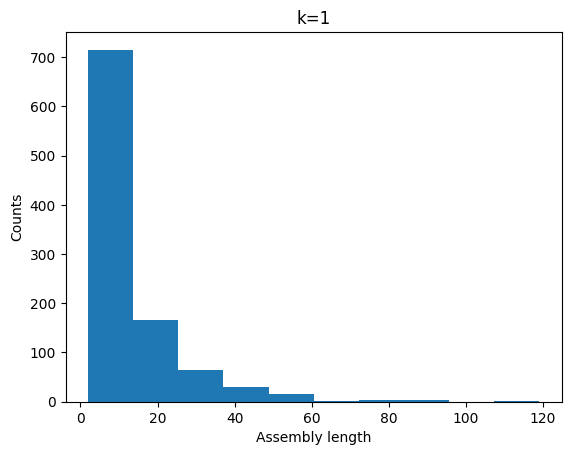

In [115]:
counts, bins = np.histogram(res[2][2])
print(counts)
print(bins)
plt.hist(bins[:-1], bins, weights=counts)
plt.xlabel("Assembly length")
plt.ylabel("Counts")
plt.title("k=1")

[536   8  27  16   3  28   2   0   0 380]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


Text(0.5, 1.0, 'k=1')

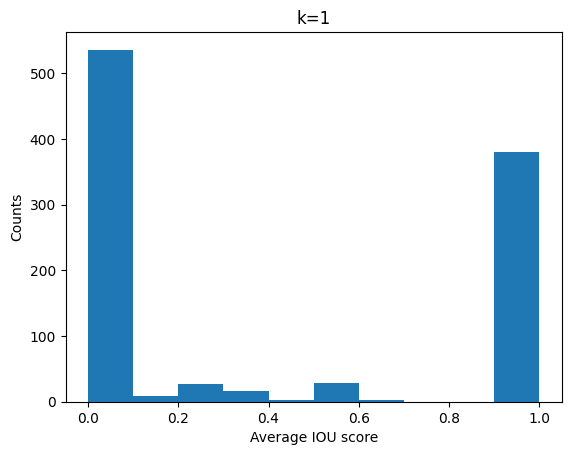

In [23]:
counts, bins = np.histogram(res[0][1])
print(counts)
print(bins)
plt.hist(bins[:-1], bins, weights=counts)
plt.xlabel("Average IOU score")
plt.ylabel("Counts")
plt.title("k=1")

In [ ]:
k = 10
for decoded_seq_dict in all_decoded_seq_list:
    ordered_decoded_seq = sorted(decoded_seq_dict.items(), key=lambda x: x[1][1])   # [(aid, (seq_list, avg_dist))]
    ordered_topk_decoded_seq = ordered_decoded_seq[:k]   # top k avg_dist [(aid, (seq_list, avg_dist))]
    iou = 0.0
    total_iou = 0.0
    total_iou_score = 0.0
    total_length_union = 0.0
    total = 0.0
    for aid, (seq, avg_dist) in ordered_topk_decoded_seq:
        aid_part_graph = all_part_graph[aid]   # obtain all the part graphs associated with aid
        aid_part_graph = transform(aid_part_graph)   # map list of md --> list of idx
        c_part = seq[0]   # central part idx
        n_parts_pred = seq[1:]   # a list of neighbouring part indices
#         c_part_dup_list = search_duplicate(c_part, aid)
#         total += len(c_part_dup_list)
        max_iou = 0   # we only record the max_iou of all the sequence considering duplicates
        max_iou_score = 0
#         cur_length_union = 0
        
        # Finding duplicates for each part in the decoded seq
        dup_map = dict()
        for part_idx in seq:
            dup_map[part_idx] = search_duplicate(part_idx, aid)
            
        for c_part in dup_map[c_part]:
            if c_part in aid_part_graph:   # if aid_part_graph contains c_part in the decoded seq, otherwise max_iou stays 0
                n_parts_true = aid_part_graph[c_part][:9]
                
                iou, iou_score = compute_iou(n_parts_pred, n_parts_true, dup_map)
                if iou > max_iou:
                    max_iou = iou
                if iou_score > max_iou_score:
                    max_iou_score = iou_score
#                     total_length_union += union
            else:
                iou = 0
                iou_score = 0
#         print(f'max_iou: {max_iou}')
        total_iou += max_iou   # compute 10 times
        total_iou_score += max_iou_score
    print(f'iou: {total_iou / k}, iou_score: {total_iou_score / k}')#', union length: {total_length_union/k}')

In [232]:
k = 1
for decoded_seq_dict in all_decoded_seq_list:
    ordered_decoded_seq = sorted(decoded_seq_dict.items(), key=lambda x: x[1][1])   # [(aid, (seq_list, avg_dist))]
    ordered_topk_decoded_seq = ordered_decoded_seq[:k]   # top k avg_dist [(aid, (seq_list, avg_dist))]
    iou = 0.0
    max_max_iou = 0.0
    max_max_iou_score = 0.0
    total_length_union = 0.0
    total = 0.0
    for aid, (seq, avg_dist) in ordered_topk_decoded_seq:
        aid_part_graph = all_part_graph[aid]   # obtain all the part graphs associated with aid
        aid_part_graph = transform(aid_part_graph)   # map list of md --> list of idx
        c_part = seq[0]   # central part idx
        n_parts_pred = seq[1:]   # a list of neighbouring part indices
#         c_part_dup_list = search_duplicate(c_part, aid)
#         total += len(c_part_dup_list)
        max_iou = 0   # we only record the max_iou of all the sequence considering duplicates
        max_iou_score = 0
#         cur_length_union = 0
        
        # Finding duplicates for each part in the decoded seq
        dup_map = dict()
        for part_idx in seq:
            dup_map[part_idx] = search_duplicate(part_idx, aid)
            
        for c_part in dup_map[c_part]:
            if c_part in aid_part_graph:   # if aid_part_graph contains c_part in the decoded seq, otherwise max_iou stays 0
                n_parts_true = aid_part_graph[c_part][:9]
                
                iou, iou_score = compute_iou(n_parts_pred, n_parts_true, dup_map)
                if iou > max_iou:
                    max_iou = iou
                if iou_score > max_iou_score:
                    max_iou_score = iou_score
#                     total_length_union += union
            else:
                iou = 0
                iou_score = 0
#         print(f'max_iou: {max_iou}')
        if max_iou > max_max_iou:
            max_max_iou = max_iou   # compute 10 times
        if max_iou_score > max_max_iou_score:
            max_max_iou_score = max_iou_score
    print(f'iou: {max_max_iou}, iou_score: {max_max_iou_score}')#', union length: {total_length_union/k}')

iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.399999520000576, iou_score: 0.25
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.49999950000050003, iou_score: 0.3333333333333333
iou: 0.0, iou_score: 0.0


# Evaluation - Display parts

In [66]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    # Width and height of the (first) image
    w, h = imgs[0].size

    # Calculate grid width and height
    grid_w = cols*w   # number of columns * width
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    # Draw the grid
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))   # put img to the correct grid cell
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(png_paths):
    num_images_per_row = 50
    k = num_images_per_row*1

            
    total_num_images = len(png_paths)
    
    if k > total_num_images:
        k = total_num_images
#     chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []  # Stores images to be displayed
#     texts = []
    for i in range(k):
        png_file = png_paths[i]
#         json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
    num_images = len(imgs)
#     sq_max = math.ceil(math.sqrt(num_images))
#     grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=None)
    grid = image_grid(imgs, 1, num_images, resize=True, texts=None)
    return grid

def extend_metadata_to_filepath(img_name_list_without_vid, vid):
    img_name_list_with_vid = []
    for i, im in enumerate(img_name_list_without_vid):
        img_name_list_with_vid.append(f'./raw_data/{vid}/{im}_00{vid}.png')
    
    return img_name_list_with_vid

def display_image_grid(msg, image_path):
    display(Markdown(msg))
#     file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")
    
def display_single_image(image_path, resize=True):
    img = Image.open(image_path)
    if resize:
        scale = 1/3
        w, h = img.size
        newsize = (int(w*scale), int(h*scale))
        img = img.resize(newsize)
    img.show()
    
    return

In [51]:
all_decoded_seq_list[0]

[[129259, (129260, 0.06694885343313217), (129259, 0.9700649380683899)],
 [53817, (53818, 0.1551254391670227), (53812, 0.9626848697662354)],
 [55125, (55134, 0.15366125106811523), (55136, 0.9570625424385071)],
 [302, (303, 0.18007336556911469), (302, 0.9702142477035522)],
 [124397, (124386, 0.35651421546936035), (124389, 0.9646685123443604)],
 [43462, (43462, 0.37309587001800537), (43462, 0.9687010645866394)],
 [109474, (109476, 0.2601713240146637), (109471, 0.9590780138969421)],
 [93736, (93732, 0.21361574530601501), (93740, 0.9649065732955933)],
 [54639, (54648, 0.16108891367912292), (54642, 0.9612194299697876)],
 [95565, (95560, 0.1300405114889145), (95556, 0.9475212693214417)]]

## Corresponding to 2. 

In [ ]:
vid = '00'
rec_seq_idx = 2
for dec_seq_idx in range(10):
    img_md_list = []
    for img_idx in all_decoded_seq_list[rec_seq_idx][dec_seq_idx]:
        img_md = all_md[img_idx]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'Reconstructed part sequence: {rec_seq_idx}, decoded part sequence: {dec_seq_idx}', img_name_list)

## Corresponding to 1. 

## For Fusion360

Original part sequence: 39

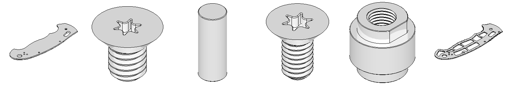

Decoded part sequence: 39

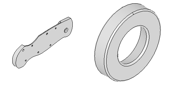

In [55]:
vid = '00'
rec_seq_idx = 39

img_md_list = []
for img_idx in all_ori_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Original part sequence: {rec_seq_idx}', img_name_list)

# vid = '00'
# rec_seq_idx = 79

img_md_list = []
for img_idx in all_rec_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Decoded part sequence: {rec_seq_idx}', img_name_list)

## For CLIP text query

Mechanism name: Double-Slider, decoded part sequence: 25

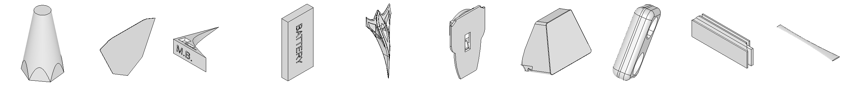

In [46]:
vid = '00'
query_seq_idx = 25
mech_names = mech_part_names['mech_name']
# part_names = mech_part_names['part_name']

img_md_list = []
for img_idx in all_query_closest_emb_list[query_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

# display_image_grid(f'Mechanism name: {mech_names[query_seq_idx]}, query: {part_names[query_seq_idx]}, decoded part sequence: {query_seq_idx}', img_name_list)
display_image_grid(f'Mechanism name: {mech_names[query_seq_idx]}, decoded part sequence: {query_seq_idx}', img_name_list)

## For ABC query

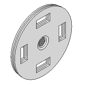

Part name: Friction rollers pair, decoded part sequence: 27

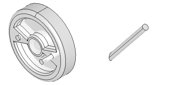

In [50]:
vid = '00'
rec_seq_idx = 27
part_name = mech_query_list[rec_seq_idx]

display_single_image(abc_md[rec_seq_idx]+'_00' + vid + '.png')

# vid = '00'
# rec_seq_idx = 79

img_md_list = []
for img_idx in all_query_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Part name: {part_name}, decoded part sequence: {rec_seq_idx}', img_name_list)

In [47]:
target = all_ori_closest_emb_list[3]

In [50]:
for res in a:
    if res[1][0][0] == target[0]:
        print(res[1][1])

## Corresponding to 3. 

parts in assembly: [133527, 133528, 133529, 133530, 133531, 133532, 133533, 133534, 133535, 133536, 133537, 133538, 133539, 133540, 133541, 133542, 133543, 133544, 133545, 133546, 133547, 133548, 133549, 133550, 133551, 133552, 133553, 133554, 133555, 133556]


decoded part sequence: 0, average distance: 0.18458817899227142, assembly id: 84374_272a9731

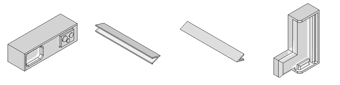

 
 
parts in assembly: [97953, 97954, 97955, 97956, 97957, 97958, 97959, 97960, 97961, 97962, 97963, 97964, 97965, 97966, 97967, 97968, 97969, 97970, 97971, 97972, 97973, 97974, 97975, 97976, 97977, 97978, 97979, 97980, 97981, 97982, 97983, 97984, 97985, 97986, 97987, 97988, 97989, 97990, 97991, 97992, 97993, 97994, 97995, 97996, 97997, 97998, 97999, 98000, 98001, 98002, 98003, 98004, 98005, 98006, 98007, 98008, 98009, 98010, 98011, 98012, 98013, 98014, 98015, 98016, 98017, 98018, 98019, 98020, 98021, 98022, 98023, 98024, 98025, 98026, 98027, 98028, 98029, 98030, 98031, 98032, 98033, 98034, 98035, 98036, 98037, 98038, 98039, 98040, 98041, 98042, 98043, 98044, 98045, 98046, 98047, 98048, 98049, 98050]


decoded part sequence: 1, average distance: 0.19145894050598145, assembly id: 43172_bebbafc3

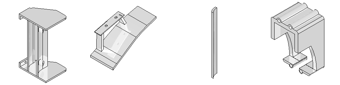

 
 
parts in assembly: [28235, 28236, 28237, 28238, 28239, 28240, 28241, 28242, 28243, 28244, 28245, 28246, 28247, 28248, 28249, 28250, 28251, 28252, 28253, 28254]


decoded part sequence: 2, average distance: 0.19337330013513565, assembly id: 136795_06c4efed

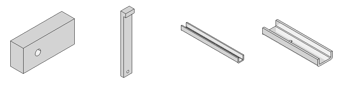

 
 
parts in assembly: [76823, 76824, 76825, 76826, 76827, 76828, 76829, 76830, 76831, 76832, 76833, 76834, 76835, 76836, 76837, 76838, 76839, 76840, 76841, 76842, 76843, 76844, 76845, 76846, 76847, 76848, 76849, 76850, 76851, 76852, 76853, 76854, 76855, 76856, 76857, 76858, 76859, 76860, 76861, 76862, 76863, 76864, 76865, 76866, 76867, 76868, 76869, 76870, 76871, 76872, 76873, 76874, 76875, 76876, 76877]


decoded part sequence: 3, average distance: 0.19350828230381012, assembly id: 31282_05c4b783

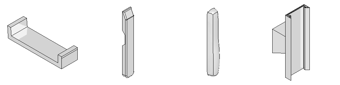

 
 
parts in assembly: [57553, 57554, 57555, 57556, 57557, 57558, 57559, 57560, 57561, 57562, 57563, 57564, 57565, 57566, 57567, 57568, 57569, 57570, 57571, 57572, 57573, 57574, 57575, 57576, 57577, 57578, 57579, 57580, 57581, 57582, 57583, 57584, 57585, 57586, 57587, 57588, 57589, 57590, 57591, 57592]


decoded part sequence: 4, average distance: 0.1936296820640564, assembly id: 23168_7fdf5427

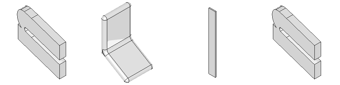

 
 
parts in assembly: [77449, 77450, 77451, 77452, 77453, 77454, 77455, 77456, 77457, 77458, 77459, 77460, 77461, 77462, 77463, 77464, 77465, 77466, 77467, 77468, 77469, 77470, 77471, 77472, 77473, 77474]


decoded part sequence: 5, average distance: 0.19398163259029388, assembly id: 31388_0d7a2c35

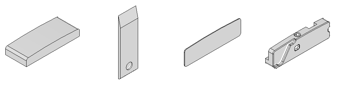

 
 
parts in assembly: [133480, 133481, 133482, 133483, 133484, 133485, 133486, 133487, 133488, 133489, 133490, 133491, 133492, 133493, 133494, 133495, 133496, 133497, 133498]


decoded part sequence: 6, average distance: 0.1952756568789482, assembly id: 84239_15bbb485

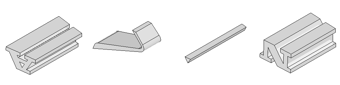

 
 
parts in assembly: [94690, 94691, 94692, 94693, 94694, 94695, 94696, 94697, 94698, 94699, 94700, 94701, 94702, 94703, 94704, 94705]


decoded part sequence: 7, average distance: 0.19598210230469704, assembly id: 41696_de0790a1

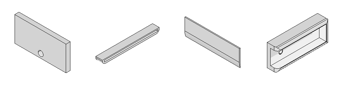

 
 
parts in assembly: [28502, 28503, 28504, 28505, 28506, 28507, 28508, 28509, 28510, 28511, 28512, 28513, 28514, 28515, 28516, 28517, 28518, 28519, 28520]


decoded part sequence: 8, average distance: 0.19856692105531693, assembly id: 136834_d1ee3f0b

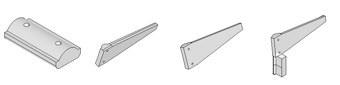

 
 
parts in assembly: [102779, 102780, 102781, 102782, 102783, 102784, 102785, 102786, 102787, 102788, 102789, 102790, 102791, 102792, 102793, 102794, 102795, 102796, 102797, 102798, 102799, 102800, 102801, 102802, 102803, 102804, 102805, 102806, 102807, 102808, 102809, 102810, 102811, 102812, 102813, 102814, 102815]


decoded part sequence: 9, average distance: 0.19880257919430733, assembly id: 49141_4dbe564e

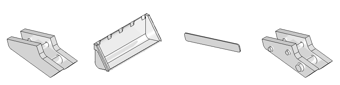

In [58]:
rec_seq_idx = 19
decoded_seq = sorted(all_decoded_seq_list[rec_seq_idx].items(), key=lambda x: x[1][1])
# print(decoded_seq[:20])

vid = '00'

img_md_list = []
for img_idx in all_ori_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Original part sequence: {rec_seq_idx}', img_name_list)

for dec_seq_idx, (aid, (indices, avg_dist)) in enumerate(decoded_seq[:10]):
    img_md_list = []
    print(f'parts in assembly: {aid_to_part_indice_map[aid]}')
    for index in indices:
        img_md = all_md[index]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'decoded part sequence: {dec_seq_idx}, average distance: {avg_dist}, assembly id: {aid}', img_name_list)

## Display the parts for a certain assembly

17


assembly id: 32839_feb1aa29

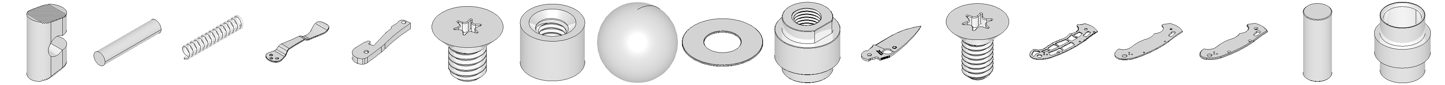

In [126]:
aid = '32839_feb1aa29'
indices = aid_to_part_indice_map[aid]
embs = all_emb[indices]
cdist = torch.cdist(embs, embs, p=2)
indices = torch.LongTensor(indices)
# indices[torch.LongTensor((cdist[7]<1e-3).nonzero(as_tuple=True)[0])].tolist()

vid = '00'
img_md_list = []
for i, index in enumerate(indices):
    img_md = all_md[index]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)
print(len(img_name_list))

display_image_grid(f'assembly id: {aid}', img_name_list)

7


assembly id: 34579_febd2016

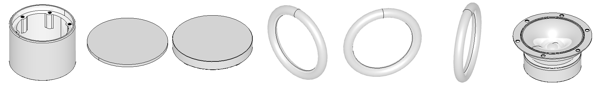

In [125]:
aid = '34579_febd2016'
indices = aid_to_part_indice_map[aid]
embs = all_emb[indices]
cdist = torch.cdist(embs, embs, p=2)
indices = torch.LongTensor(indices)
# indices[torch.LongTensor((cdist[7]<1e-3).nonzero(as_tuple=True)[0])].tolist()

vid = '00'
img_md_list = []
for i, index in enumerate(indices):
    img_md = all_md[index]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)
print(len(img_name_list))

display_image_grid(f'assembly id: {aid}', img_name_list)

# Understand retrieval experiments

In [102]:
results = load_json("model_outputs/result_retrieve_1_another_run.json")

In [103]:
len(results)

1124

In [ ]:
list(range(len(all_emb)))

In [104]:
vid = '00'
valid_indices = []
    
for seq in results:
    if len(seq["matching_neighbouring_bodies_k"]) > 0:
        valid_indices.append(seq["sequence_index"])

137104_1259ae07
0000_137104_1259ae07_61c46a1e-05b5-11ec-8d51-0226f5980261_0000
0000_137104_1259ae07_61c37fcc-05b5-11ec-9b3d-0226f5980261_0000
0000_137104_1259ae07_61c30a7e-05b5-11ec-896d-0226f5980261_0000
0000_137104_1259ae07_61c24722-05b5-11ec-b3ec-0226f5980261_0000
0000_137104_1259ae07_61c09966-05b5-11ec-823d-0226f5980261_0000


Decoded part sequence index: 24, iou_network: 0.75, iou_random: 0.385

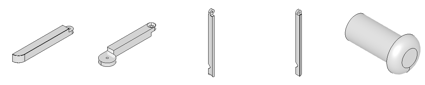

Original part sequence (in training set):

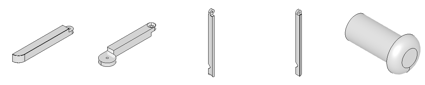

Original part sequence (in test set) index: 24, no. assembly bodies: 11, no. assembly contacts: 21

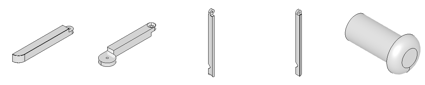

 
 
32839_feb1aa29
0000_32839_feb1aa29_7ad187d0-0545-11ec-83a9-02d1834e9dbb_0000
0000_32839_feb1aa29_7ac37e1e-0545-11ec-af11-02d1834e9dbb_0000
0000_32839_feb1aa29_7ae84458-0545-11ec-ab19-02d1834e9dbb_0000


Decoded part sequence index: 33, iou_network: 0.0, iou_random: 0.14

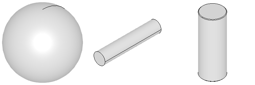

Original part sequence (in training set):

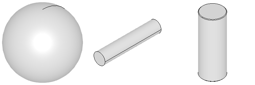

Original part sequence (in test set) index: 33, no. assembly bodies: 17, no. assembly contacts: 29

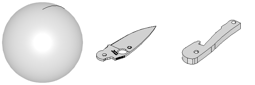

 
 
45424_63abf99e
0000_45424_63abf99e_c8c46c1e-057d-11ec-8cbe-0aa144729c8d_0000
0000_45424_63abf99e_c8c6b5b0-057d-11ec-b4c2-0aa144729c8d_0000
0000_45424_63abf99e_c8c66780-057d-11ec-8c57-0aa144729c8d_0000
0000_45424_63abf99e_c8c5f2e4-057d-11ec-b48c-0aa144729c8d_0000
0000_45424_63abf99e_c8c57d9c-057d-11ec-bc6b-0aa144729c8d_0000
0000_45424_63abf99e_c8c5089e-057d-11ec-a7d4-0aa144729c8d_0000
0000_45424_63abf99e_c8c64092-057d-11ec-be70-0aa144729c8d_0000
0000_45424_63abf99e_c8c5cbb0-057d-11ec-8596-0aa144729c8d_0000
0000_45424_63abf99e_c8c4e164-057d-11ec-a23f-0aa144729c8d_0000
0000_45424_63abf99e_c8c55692-057d-11ec-9502-0aa144729c8d_0000


Decoded part sequence index: 69, iou_network: 0.2222222222222222, iou_random: 0.22222222222222224

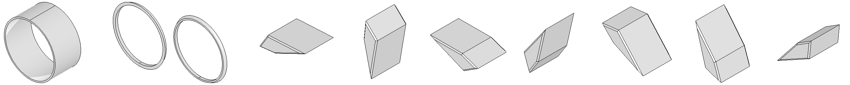

Original part sequence (in training set):

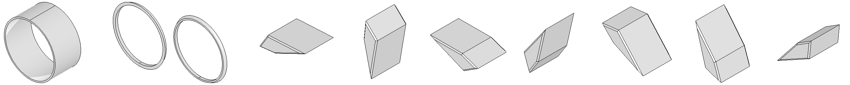

Original part sequence (in test set) index: 69, no. assembly bodies: 10, no. assembly contacts: 2

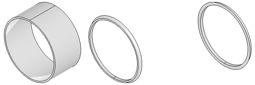

 
 
27655_04ca3d07
0000_27655_04ca3d07_1ca727fe-0563-11ec-a4b8-02222d9c29db_0000
0000_27655_04ca3d07_1ca6b2b6-0563-11ec-8b09-02222d9c29db_0000
0000_27655_04ca3d07_1ca09840-0563-11ec-9db3-02222d9c29db_0000
0000_27655_04ca3d07_1caa5c8a-0563-11ec-95f3-02222d9c29db_0000


Decoded part sequence index: 82, iou_network: 0.3333333333333333, iou_random: 0.15333333333333332

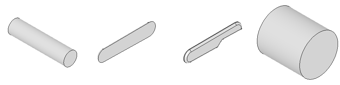

Original part sequence (in training set):

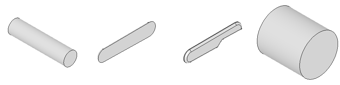

Original part sequence (in test set) index: 82, no. assembly bodies: 22, no. assembly contacts: 38

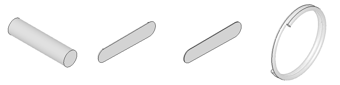

 
 
27655_04ca3d07
0000_27655_04ca3d07_1caaaa52-0563-11ec-805a-02222d9c29db_0000
0000_27655_04ca3d07_1ca6b2b6-0563-11ec-8b09-02222d9c29db_0000
0000_27655_04ca3d07_1ca09840-0563-11ec-9db3-02222d9c29db_0000


Decoded part sequence index: 90, iou_network: 0.5, iou_random: 0.23

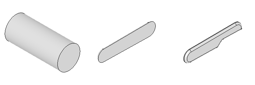

Original part sequence (in training set):

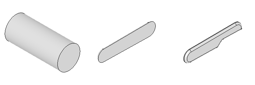

Original part sequence (in test set) index: 90, no. assembly bodies: 22, no. assembly contacts: 38

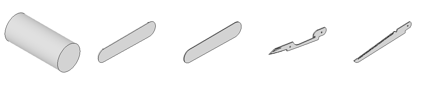

 
 
27655_04ca3d07
0000_27655_04ca3d07_1cab1f86-0563-11ec-80a4-02222d9c29db_0000
0000_27655_04ca3d07_1ca6b2b6-0563-11ec-8b09-02222d9c29db_0000
0000_27655_04ca3d07_1ca09840-0563-11ec-9db3-02222d9c29db_0000


Decoded part sequence index: 91, iou_network: 0.5, iou_random: 0.13

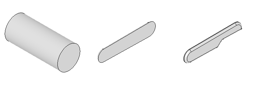

Original part sequence (in training set):

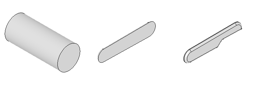

Original part sequence (in test set) index: 91, no. assembly bodies: 22, no. assembly contacts: 38

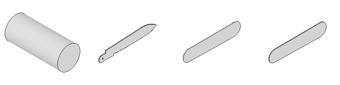

 
 
67221_275ba7e6
0000_67221_275ba7e6_11a9561e-059a-11ec-ab22-0ac51587b959_0000
0000_67221_275ba7e6_11a8e124-059a-11ec-a050-0ac51587b959_0000
0000_67221_275ba7e6_11a2c65c-059a-11ec-b18d-0ac51587b959_0000
0000_67221_275ba7e6_11f4de02-059a-11ec-a232-0ac51587b959_0000


Decoded part sequence index: 155, iou_network: 0.0, iou_random: 0.09666666666666666

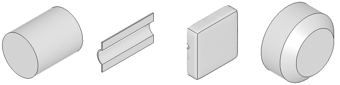

Original part sequence (in training set):

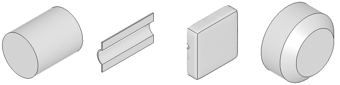

Original part sequence (in test set) index: 155, no. assembly bodies: 31, no. assembly contacts: 24

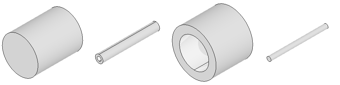

 
 
67221_275ba7e6
0000_67221_275ba7e6_11a9a42e-059a-11ec-9ed1-0ac51587b959_0000
0000_67221_275ba7e6_11a8e124-059a-11ec-a050-0ac51587b959_0000
0000_67221_275ba7e6_11a2c65c-059a-11ec-b18d-0ac51587b959_0000
0000_67221_275ba7e6_11f4de02-059a-11ec-a232-0ac51587b959_0000


Decoded part sequence index: 156, iou_network: 0.0, iou_random: 0.056666666666666664

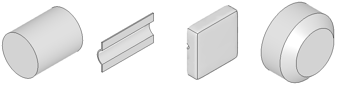

Original part sequence (in training set):

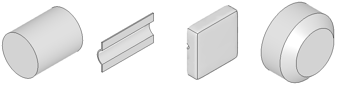

Original part sequence (in test set) index: 156, no. assembly bodies: 31, no. assembly contacts: 24

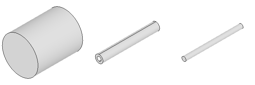

 
 
67221_275ba7e6
0000_67221_275ba7e6_11d4369e-059a-11ec-89d9-0ac51587b959_0000
0000_67221_275ba7e6_11d3e866-059a-11ec-bdb6-0ac51587b959_0000


Decoded part sequence index: 161, iou_network: 1.0, iou_random: 0.02

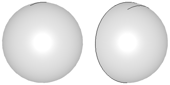

Original part sequence (in training set):

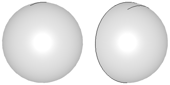

Original part sequence (in test set) index: 161, no. assembly bodies: 31, no. assembly contacts: 24

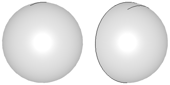

 
 
36527_06b92981
0000_36167_4878e430_1563cf3a-0530-11ec-8ae2-020a4e46e3ef_0000
0000_36527_06b92981_d6eafd4c-0535-11ec-9c58-0acddec473cb_0000


Decoded part sequence index: 182, iou_network: 1.0, iou_random: 0.34

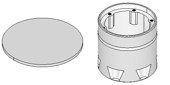

Original part sequence (in training set):

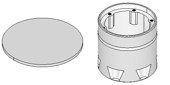

Original part sequence (in test set) index: 182, no. assembly bodies: 4, no. assembly contacts: 3

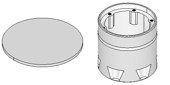

 
 
36527_06b92981
0000_34579_febd2016_b82f34e8-05d1-11ec-972e-0288f32f2721_0000
0000_36527_06b92981_d6eafd4c-0535-11ec-9c58-0acddec473cb_0000


Decoded part sequence index: 184, iou_network: 1.0, iou_random: 0.34

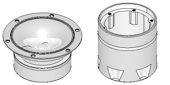

Original part sequence (in training set):

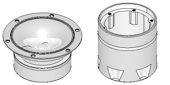

Original part sequence (in test set) index: 184, no. assembly bodies: 4, no. assembly contacts: 3

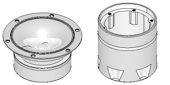

 
 
138748_a3e7a578
0000_138748_a3e7a578_3c26d276-05d3-11ec-a67d-02d1834e9dbb_0000
0000_138748_a3e7a578_3c337bec-05d3-11ec-bfb6-02d1834e9dbb_0000
0000_138748_a3e7a578_3c26f8f8-05d3-11ec-baa8-02d1834e9dbb_0000


Decoded part sequence index: 192, iou_network: 0.0, iou_random: 0.015

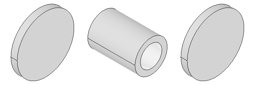

Original part sequence (in training set):

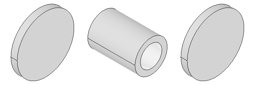

Original part sequence (in test set) index: 192, no. assembly bodies: 51, no. assembly contacts: 11

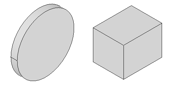

 
 
138748_a3e7a578
0000_138748_a3e7a578_3c26f8f8-05d3-11ec-baa8-02d1834e9dbb_0000
0000_138748_a3e7a578_3c26d276-05d3-11ec-a67d-02d1834e9dbb_0000


Decoded part sequence index: 193, iou_network: 0.0, iou_random: 0.02

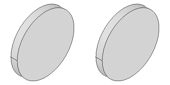

Original part sequence (in training set):

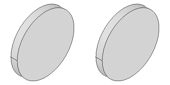

Original part sequence (in test set) index: 193, no. assembly bodies: 51, no. assembly contacts: 11

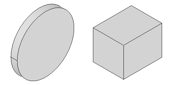

 
 
138748_a3e7a578
0000_138748_5721b4fa_be6136ec-0557-11ec-a6d0-0690942d3ea3_0000
0000_138748_a3e7a578_3c24fd02-05d3-11ec-a1eb-02d1834e9dbb_0000
0000_138748_a3e7a578_3c276e40-05d3-11ec-b015-02d1834e9dbb_0000


Decoded part sequence index: 194, iou_network: 1.0, iou_random: 0.015

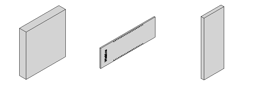

Original part sequence (in training set):

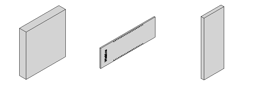

Original part sequence (in test set) index: 194, no. assembly bodies: 51, no. assembly contacts: 11

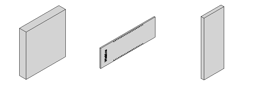

 
 
138748_a3e7a578
0000_138748_a3e7a578_3c276e40-05d3-11ec-b015-02d1834e9dbb_0000
0000_138748_a3e7a578_3c24fd02-05d3-11ec-a1eb-02d1834e9dbb_0000
0000_138748_5721b4fa_be6136ec-0557-11ec-a6d0-0690942d3ea3_0000


Decoded part sequence index: 195, iou_network: 1.0, iou_random: 0.05

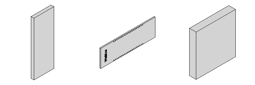

Original part sequence (in training set):

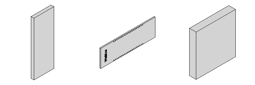

Original part sequence (in test set) index: 195, no. assembly bodies: 51, no. assembly contacts: 11

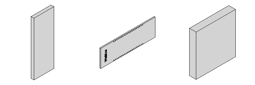

 
 
138748_a3e7a578
0000_138748_a3e7a578_3c38ac0a-05d3-11ec-882d-02d1834e9dbb_0000
0000_138748_a3e7a578_3c24fd02-05d3-11ec-a1eb-02d1834e9dbb_0000


Decoded part sequence index: 196, iou_network: 1.0, iou_random: 0.01

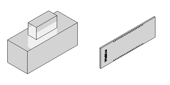

Original part sequence (in training set):

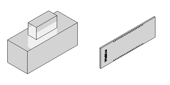

Original part sequence (in test set) index: 196, no. assembly bodies: 51, no. assembly contacts: 11

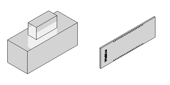

 
 
41718_fff89442
0000_41718_fff89442_8590303e-057a-11ec-9536-0ace72c19443_0000
0000_41718_fff89442_85956052-057a-11ec-a8ee-0ace72c19443_0000
0000_41718_fff89442_8592a118-057a-11ec-aedb-0ace72c19443_0000


Decoded part sequence index: 200, iou_network: 0.0, iou_random: 0.045

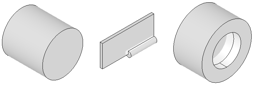

Original part sequence (in training set):

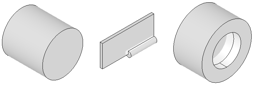

Original part sequence (in test set) index: 200, no. assembly bodies: 22, no. assembly contacts: 24

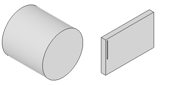

 
 
41718_fff89442
0000_41718_fff89442_8590a54a-057a-11ec-b5e2-0ace72c19443_0000
0000_41718_fff89442_8592a118-057a-11ec-aedb-0ace72c19443_0000
0000_41718_fff89442_85951192-057a-11ec-8ee3-0ace72c19443_0000


Decoded part sequence index: 201, iou_network: 0.0, iou_random: 0.05

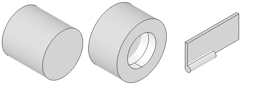

Original part sequence (in training set):

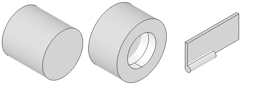

Original part sequence (in test set) index: 201, no. assembly bodies: 22, no. assembly contacts: 24

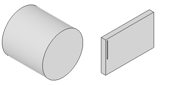

 
 
41718_fff89442
0000_41718_fff89442_8590f374-057a-11ec-9127-0ace72c19443_0000
0000_41718_fff89442_859168a4-057a-11ec-9bab-0ace72c19443_0000
0000_41718_fff89442_8595d5ba-057a-11ec-bab8-0ace72c19443_0000


Decoded part sequence index: 202, iou_network: 0.5, iou_random: 0.04

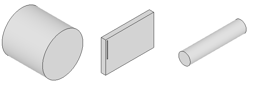

Original part sequence (in training set):

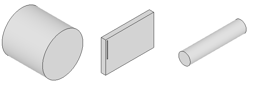

Original part sequence (in test set) index: 202, no. assembly bodies: 22, no. assembly contacts: 24

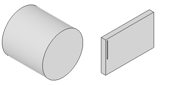

 
 
41718_fff89442
0000_41718_fff89442_85911adc-057a-11ec-9967-0ace72c19443_0000
0000_41718_fff89442_8592a118-057a-11ec-aedb-0ace72c19443_0000
0000_41718_fff89442_85951192-057a-11ec-8ee3-0ace72c19443_0000


Decoded part sequence index: 203, iou_network: 0.0, iou_random: 0.065

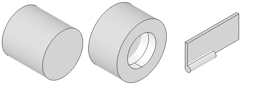

Original part sequence (in training set):

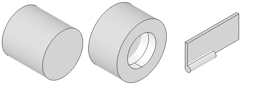

Original part sequence (in test set) index: 203, no. assembly bodies: 22, no. assembly contacts: 24

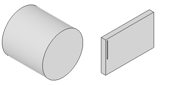

In [122]:
indices = range(10, 30)
for index in indices:
#     sequence_index = valid_indices[index]
#     result = results[sequence_index]
    result = results[index]
    if len(result["matching_neighbouring_bodies_k"]) == 0:
        continue
    sequence_index = result["sequence_index"]
    result_aid = result["assembly_id"]
    print(result_aid)
    result_c_body_id = result["central_body_id"]
    result_neigh_bodies = result["matching_neighbouring_bodies_k"][0]["matching_neighboring_bodies"]
    result_iou_network = result["matching_neighbouring_bodies_k"][0]["iou_network"]
    result_iou_random = result["matching_neighbouring_bodies_k"][0]["random_baseline_iou"]
    result_a_size = result["assembly_num_bodies"]
    result_contacts = result["assembly_num_contacts"]

    img_name_list = []
    img_name_list.append(f"./raw_data/{vid}/0000_{result_aid}_{result_c_body_id}_0000_00{vid}.png")
    
    img_name_in_train_list = []
    img_idx, dist = find_closest(all_emb[md_to_idx_map[f"0000_{result_aid}_{result_c_body_id}_0000"]])
    img_md = all_md[img_idx]
    print(img_md)
    img_name_in_train_list.append(f"./raw_data/{vid}/{img_md}_00{vid}.png")

    for result_neigh_body_id in result_neigh_bodies:
        img_name = f"./raw_data/{vid}/0000_{result_aid}_{result_neigh_body_id}_0000_00{vid}.png"
        img_name_list.append(img_name)
        
        img_idx, dist = find_closest(all_emb[md_to_idx_map[f"0000_{result_aid}_{result_neigh_body_id}_0000"]])
        img_md = all_md[img_idx]
        print(img_md)
        img_name_in_train_list.append(f"./raw_data/{vid}/{img_md}_00{vid}.png")

    display_image_grid(f'Decoded part sequence index: {sequence_index}, iou_network: {result_iou_network}, iou_random: {result_iou_random}', img_name_list)
    display_image_grid(f'Original part sequence (in training set):', img_name_in_train_list)

    img_md_list = []
    for img_idx in all_ori_closest_emb_list[sequence_index]:
        img_md = all_md[img_idx]
        img_md_list.append(img_md)

    img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'Original part sequence (in test set) index: {sequence_index}, no. assembly bodies: {result_a_size}, no. assembly contacts: {result_contacts}', img_name_list)
